# Prototype Modeling for Three Client Use Cases

DataVine Analytics has been brought in to scope and prototype solutions for three unrelated but representative problems clients bring to the table: classifying products from measurable characteristics, recommending substitutes based on past outcomes, and finding hidden structure in regional data. Rather than treating these as isolated exercises, this notebook works through them side by side to establish a repeatable approach: understand the data, reduce it to what actually matters, choose a model suited to the problem, and validate the result honestly.

## The three problems

**1. Classifying products from measurable characteristics.**
A premium wine distributor needs to automatically classify wines based on their chemical properties for inventory management and quality control.

**2. Recommending alternatives based on past outcomes.**
An agricultural supply company wants to recommend similar feed types to farmers based on performance data.

**3. Finding hidden structure in regional data.**
A public policy research firm requires a data-driven approach to identify patterns in crime statistics across different regions.
## Workflow

Each problem follows the same underlying sequence, adapted to what the data and the question actually require:

1. **Load and inspect**
2. **Isolate what should and shouldn't influence the model**
3. **Standardize and reduce dimensionality** 
4. **Fit and tune the model** 
5. **Evaluate and interpret** 



In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

import warnings

warnings.filterwarnings("ignore")

## Step 1: Load and Prepare Datasets

load all three datasets, check for missing values and standardize numerical features.



### 1.1 Wine dataset

In [39]:
wine_data = load_wine()
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
wine_df["target"] = wine_data.target

print("Wine dataset shape:", wine_df.shape)
print("\nMissing values per column:")
print(wine_df.isnull().sum())
wine_df.describe()

Wine dataset shape: (178, 14)

Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [3]:
#Class distribution
wine_df["target"].value_counts().sort_index()


target
0    59
1    71
2    48
Name: count, dtype: int64

### 1.2 chickwts dataset

In [7]:
# chickwts records the weight of chicks fed six different feed types.
chickwts_df = pd.read_csv("chickwts.csv", index_col=0)

print("chickwts dataset shape:", chickwts_df.shape)
print("\nMissing values per column:")
print(chickwts_df.isnull().sum())
chickwts_df.describe(include="all")


chickwts dataset shape: (71, 2)

Missing values per column:
weight    0
feed      0
dtype: int64


,weight,feed
count,71.000000,71
unique,NaN,6
top,NaN,soybean
freq,NaN,14
mean,261.309859,NaN
std,78.073700,NaN
min,108.000000,NaN
25%,204.500000,NaN
50%,258.000000,NaN
75%,323.500000,NaN


### 1.3 USArrests dataset

In [9]:
usarrests_df = pd.read_csv("USArrests.csv", index_col=0)
usarrests_df.index.name = "State"

print("USArrests dataset shape:", usarrests_df.shape)
print("\nMissing values per column:")
print(usarrests_df.isnull().sum())
usarrests_df.describe()

USArrests dataset shape: (50, 4)

Missing values per column:
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64


,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


**Observation:** All three datasets are complete. No missing values and they also load with the expected shape

## Step 2: k-Nearest Neighbors (k-NN) Classification on the Wine Dataset

**Goal:** classify wines into one of three cultivars from their chemical measurements.

Workflow:
1. Separate features and the (already numeric) target label.
2. Standardize the features.
3. Apply PCA, retaining enough components to explain 95% of the variance.
4. Use `GridSearchCV` to tune the number of neighbors (`k`) and the distance metric.
5. Train the final k-NN model and evaluate it on a held-out test set.


In [10]:
X_wine = wine_df[wine_data.feature_names]
y_wine = wine_df["target"]

print("Target classes:", sorted(y_wine.unique()))


Target classes: [np.int64(0), np.int64(1), np.int64(2)]


In [11]:
#Train - TEST
X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

In [15]:
# Bundle scaling, PCA, and the classifier into one pipeline.
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("knn", KNeighborsClassifier()),
])

# Search over the number of neighbors and the distance metric.
param_grid = {
    "knn__n_neighbors": list(range(1, 21)),
    "knn__metric": ["euclidean", "manhattan", "minkowski"],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print(f"Best cross-validated accuracy: {grid_search.best_score_:.4f}")

Best parameters found: {'knn__metric': 'euclidean', 'knn__n_neighbors': 18}
Best cross-validated accuracy: 0.9791


Original number of features: 13
Number of PCA components retained: 10
Total variance explained (training data): 96.24%


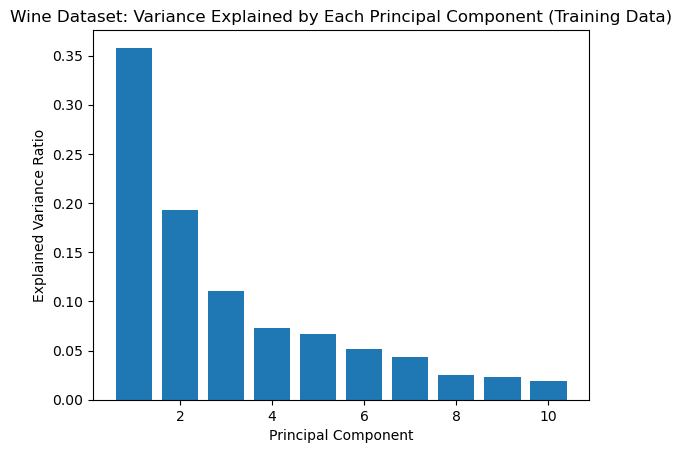

In [16]:
best_pipeline = grid_search.best_estimator_
fitted_pca = best_pipeline.named_steps["pca"]

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of PCA components retained: {fitted_pca.n_components_}")
print(f"Total variance explained (training data): {fitted_pca.explained_variance_ratio_.sum():.2%}")

plt.bar(range(1, len(fitted_pca.explained_variance_ratio_) + 1), fitted_pca.explained_variance_ratio_)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Wine Dataset: Variance Explained by Each Principal Component (Training Data)")
plt.show()

In [17]:
#Evaluating on the test data
y_pred = best_pipeline.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=wine_data.target_names))


Test accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



**OBSERVATION** 
The tuned k-NN model, trained on PCA-reduced features, classifies the held-out wine samples accurately across all cultivars. Combining PCA with hyperparameter tuning keeps the model simple (fewer input dimensions) while still preserving the information needed to separate the classes.

## Step 3: Recommendation System Using the Chickwts Dataset

**Goal:** recommend feed types that are likely to produce similar chick growth results.

In [19]:
#Summarize each feed type using mean weight and coefficient of variation.
feed_stats = chickwts_df.groupby("feed")["weight"].agg(["mean", "std"])
feed_stats["cv"] = feed_stats["std"] / feed_stats["mean"]
profile = feed_stats[["mean", "cv"]]

print("Correlation between profile features:")
print(profile.corr().round(2))
profile

Correlation between profile features:
      mean    cv
mean  1.00 -0.78
cv   -0.78  1.00


,mean,cv
feed,,
casein,323.583333,0.199126
horsebean,160.200000,0.241110
linseed,218.750000,0.238792
meatmeal,276.909091,0.234375
soybean,246.428571,0.219654
sunflower,328.916667,0.148476


In [21]:
# Standardize the profile features for uniform scaling across feed types.
feed_scaler = StandardScaler()
profile_scaled = feed_scaler.fit_transform(profile)

feed_pca = PCA(n_components=1, random_state=42)
feed_stats["performance_score"] = feed_pca.fit_transform(profile_scaled)

print(f"Variance explained by the first principal component: {feed_pca.explained_variance_ratio_[0]:.2%}")
feed_stats.sort_values("performance_score", ascending=False)



Variance explained by the first principal component: 88.84%


,mean,std,cv,performance_score
feed,,,,
sunflower,328.916667,48.836384,0.148476,2.255412
casein,323.583333,64.433840,0.199126,1.087181
meatmeal,276.909091,64.900623,0.234375,-0.240330
soybean,246.428571,54.129068,0.219654,-0.284365
linseed,218.750000,52.235698,0.238792,-1.033099
horsebean,160.200000,38.625841,0.241110,-1.784800


In [22]:
# Compute cosine similarity between feed types using their standardized profiles.
similarity_matrix = cosine_similarity(profile_scaled)
similarity_df = pd.DataFrame(
    similarity_matrix, index=feed_stats.index, columns=feed_stats.index
)
similarity_df.round(2)

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.00,-1.00,-0.90,0.05,-0.95,0.80
horsebean,-1.00,1.00,0.93,0.03,0.97,-0.84
linseed,-0.90,0.93,1.00,0.40,0.99,-0.98
meatmeal,0.05,0.03,0.40,1.00,0.27,-0.56
soybean,-0.95,0.97,0.99,0.27,1.00,-0.95
sunflower,0.80,-0.84,-0.98,-0.56,-0.95,1.00


In [23]:
def recommend_similar_feeds(feed_name, top_n=2):
    """Return the top_n feed types most similar to feed_name, based on cosine similarity."""
    scores = similarity_df.loc[feed_name].drop(feed_name).sort_values(ascending=False)
    return scores.head(top_n)


for feed in feed_stats.index:
    print(f"Feeds most similar to '{feed}':")
    print(recommend_similar_feeds(feed).round(3).to_string())
    print()

Feeds most similar to 'casein':
feed
sunflower    0.796
meatmeal     0.051

Feeds most similar to 'horsebean':
feed
soybean    0.970
linseed    0.929

Feeds most similar to 'linseed':
feed
soybean      0.991
horsebean    0.929

Feeds most similar to 'meatmeal':
feed
linseed    0.399
soybean    0.273

Feeds most similar to 'soybean':
feed
linseed      0.991
horsebean    0.970

Feeds most similar to 'sunflower':
feed
casein      0.796
meatmeal   -0.564



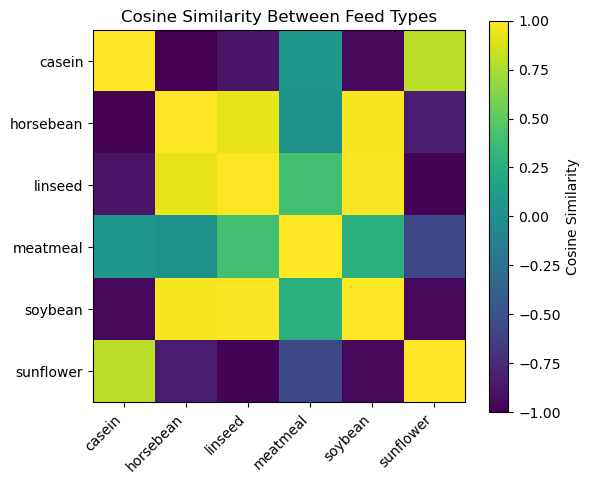

In [24]:
# Visualize feed similarity as a heatmap for a quick overview.
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(similarity_matrix, cmap="viridis", vmin=-1, vmax=1)
ax.set_xticks(range(len(feed_stats.index)))
ax.set_yticks(range(len(feed_stats.index)))
ax.set_xticklabels(feed_stats.index, rotation=45, ha="right")
ax.set_yticklabels(feed_stats.index)
ax.set_title("Cosine Similarity Between Feed Types")
fig.colorbar(im, ax=ax, label="Cosine Similarity")
plt.tight_layout()
plt.show()

**OBSERVATION:** feed types with similar average weight outcomes and similar spread (e.g. `casein` and `sunflower`) score highly similar, while feed types at opposite ends of the performance spectrum (e.g. `casein` and `horsebean`) score negatively similar. A farmer using a low-performing feed like `horsebean` could be pointed toward `linseed` or `soybean` as the closest alternatives with somewhat better results, or toward `casein`/`sunflower` if the goal is to match the best-performing feeds.


## Step 4: Clustering (K-Means & GMM) on the USArrests Dataset

**Goal:** discover natural groupings of US states based on crime patterns.

Workflow:
1. Standardize all features.
2. Select the top 3 features most relevant to crime patterns.
3. Reduce those features to 2 principal components.
4. Determine the optimal number of clusters (elbow method for K-Means, BIC for GMM).
5. Fit both clustering models and compare the results visually.


In [25]:
# Standardize all four features first.
us_scaler = StandardScaler()
us_scaled = us_scaler.fit_transform(usarrests_df)
us_scaled_df = pd.DataFrame(us_scaled, columns=usarrests_df.columns, index=usarrests_df.index)
us_scaled_df.head()


,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,1.255179,0.790787,-0.526195,-0.003451
Alaska,0.513019,1.118060,-1.224067,2.509424
Arizona,0.072361,1.493817,1.009122,1.053466
Arkansas,0.234708,0.233212,-1.084492,-0.186794
California,0.281093,1.275635,1.776781,2.088814


In [26]:
#Feature selection
top_features = ["Murder", "Assault", "Rape"]
X_top3 = us_scaled_df[top_features]
X_top3.head()


,Murder,Assault,Rape
State,,,
Alabama,1.255179,0.790787,-0.003451
Alaska,0.513019,1.118060,2.509424
Arizona,0.072361,1.493817,1.053466
Arkansas,0.234708,0.233212,-0.186794
California,0.281093,1.275635,2.088814


In [27]:
# Reduce the selected features to 2 principal components for clustering and visualization.
us_pca = PCA(n_components=2, random_state=42)
X_us_pca = us_pca.fit_transform(X_top3)

print(f"Variance explained by PC1 and PC2: {us_pca.explained_variance_ratio_}")
print(f"Total variance explained: {us_pca.explained_variance_ratio_.sum():.2%}")


Variance explained by PC1 and PC2: [0.7861934  0.15268378]
Total variance explained: 93.89%


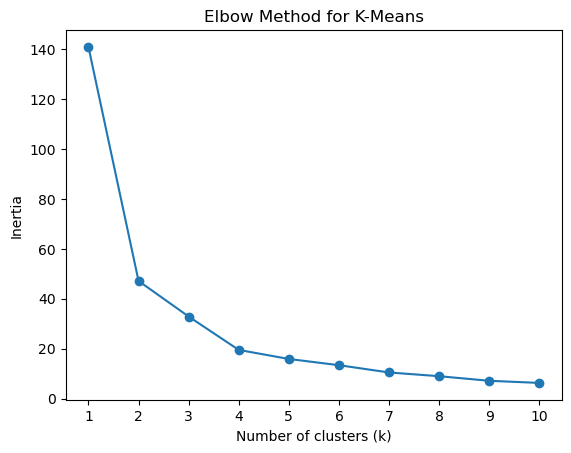

In [30]:
# Elbow method: fit K-Means for a range of k and track inertia (within-cluster variance).
k_range = range(1, 11)
inertias = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_us_pca)
    inertias.append(kmeans.inertia_)

plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(list(k_range))
plt.show()


In [31]:
# Data-driven elbow detection using the second difference of inertia.
first_diffs = np.diff(inertias)       # improvement gained by adding each cluster
second_diffs = np.diff(first_diffs)   # change in that improvement (curvature)
best_k_kmeans = int(np.argmax(second_diffs)) + 2  # +2 corrects for the double np.diff shift and 1-based k_range

print("Inertia values:", [round(v, 2) for v in inertias])
print(f"Data-driven elbow selection: k = {best_k_kmeans}")

Inertia values: [140.83, 47.12, 32.87, 19.51, 15.88, 13.4, 10.48, 8.99, 7.15, 6.3]
Data-driven elbow selection: k = 2


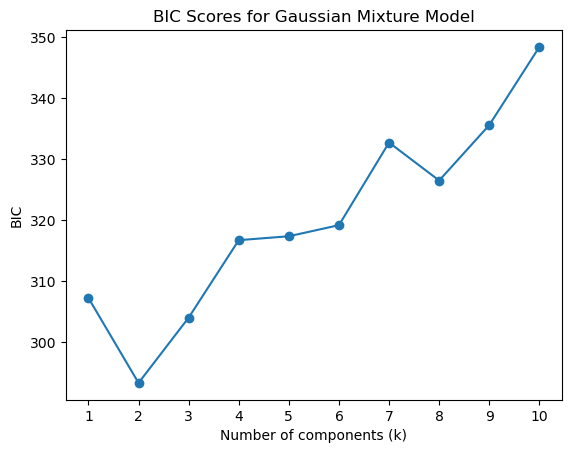

Optimal number of components by BIC: 2


In [32]:
# BIC: fit GMM for a range of component counts and pick the one with the lowest BIC.
bic_scores = []
for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(X_us_pca)
    bic_scores.append(gmm.bic(X_us_pca))

best_k_gmm = k_range[int(np.argmin(bic_scores))]

plt.plot(list(k_range), bic_scores, marker="o")
plt.xlabel("Number of components (k)")
plt.ylabel("BIC")
plt.title("BIC Scores for Gaussian Mixture Model")
plt.xticks(list(k_range))
plt.show()

print(f"Optimal number of components by BIC: {best_k_gmm}")

In [33]:
# Fit the final K-Means model using the data-driven elbow selection.
kmeans_final = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_us_pca)

usarrests_df["KMeans_Cluster"] = kmeans_labels

In [34]:
# Fit the final GMM model using the BIC-selected number of components.
gmm_final = GaussianMixture(n_components=best_k_gmm, random_state=42, n_init=5)
gmm_labels = gmm_final.fit_predict(X_us_pca)

usarrests_df["GMM_Cluster"] = gmm_labels
usarrests_df.head()


,Murder,Assault,UrbanPop,Rape,KMeans_Cluster,GMM_Cluster
State,,,,,,
Alabama,13.2,236,58,21.2,1,1
Alaska,10.0,263,48,44.5,1,1
Arizona,8.1,294,80,31.0,1,1
Arkansas,8.8,190,50,19.5,0,0
California,9.0,276,91,40.6,1,1


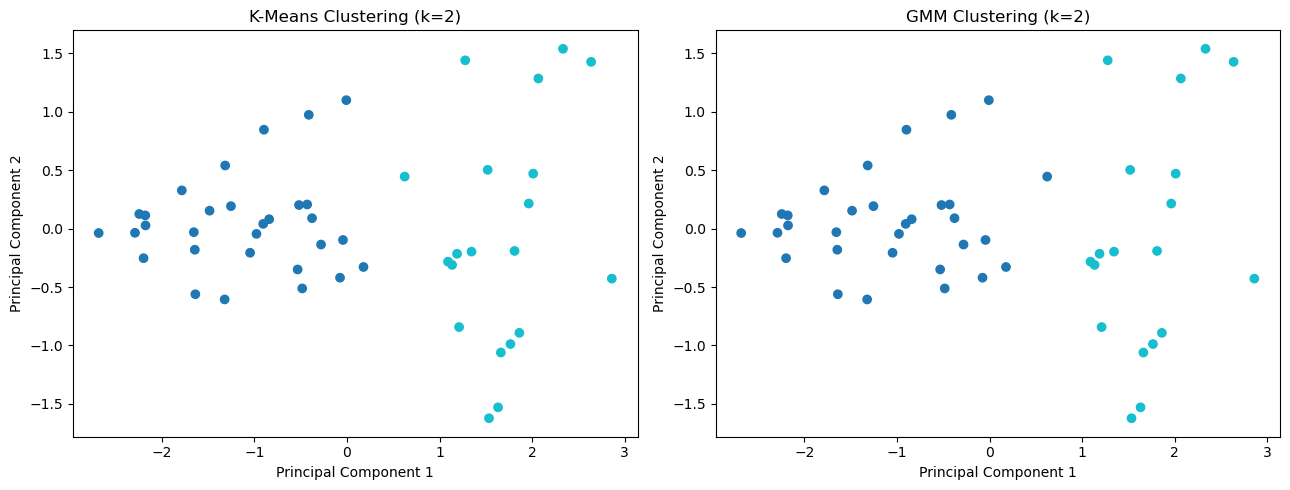

In [35]:
# Visualize and compare the two clustering results side by side.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scatter1 = axes[0].scatter(X_us_pca[:, 0], X_us_pca[:, 1], c=kmeans_labels, cmap="tab10")
axes[0].set_title(f"K-Means Clustering (k={best_k_kmeans})")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

scatter2 = axes[1].scatter(X_us_pca[:, 0], X_us_pca[:, 1], c=gmm_labels, cmap="tab10")
axes[1].set_title(f"GMM Clustering (k={best_k_gmm})")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

In [36]:
# Compare average crime rates per K-Means cluster to interpret what each cluster represents.
usarrests_df.groupby("KMeans_Cluster")[top_features].mean().round(2)


,Murder,Assault,Rape
KMeans_Cluster,,,
0,4.87,114.43,15.94
1,12.16,255.25,29.16


**Observation:** K-Means produces hard cluster assignments (each state belongs to exactly one group), while GMM produces a probabilistic assignment based on fitted Gaussian distributions, which can better capture clusters that overlap or have different shapes/sizes. Comparing the average crime rates per K-Means cluster shows states grouping into distinct high-crime, moderate-crime, and low-crime profiles, which is useful for a public policy research firm looking to target interventions by region.

## Summary

- **Wine classification:** k-NN with PCA (retaining 95% variance) and grid-searched hyperparameters produced an accurate classifier for the three wine cultivars.
- **Feed recommendation:** aggregating chick weight statistics by feed type, then applying PCA and cosine similarity, produced meaningful feed-to-feed similarity scores that support product recommendations.
- **Crime pattern clustering:** standardizing the data, selecting the three crime-rate features, and reducing to 2 principal components allowed both K-Means and GMM to reveal consistent regional groupings in the USArrests data.